# Predicting Online Purchase Intention from Web Session Behaviour

This notebook investigates whether e-commerce browsing sessions can be classified as purchase or non-purchase sessions using supervised machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# A fixed random state is used so that the train/test split and model results are reproducible.
RANDOM_STATE = 42

## Initial data examination

In [2]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


The first rows show that each record represents one online shopping session. The target variable is `Revenue`, which shows whether the session ended in a purchase.

The input features describe browsing behaviour, timing and visitor/session information. These include page counts, page durations, rates such as `BounceRates` and `ExitRates`, `PageValues`, `Month`, `VisitorType`, `Weekend` and coded technical features such as `Browser`, `Region` and `TrafficType`.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The `df.info()` output shows that the dataset has 12,330 rows and 18 columns. All columns have 12,330 non-null values, so there are no missing values shown at this stage.

The data contains a mixture of integers, floats, strings and Boolean values. This means preprocessing will be needed before modelling, especially for categorical variables and Boolean values.

In [4]:
summary_checks = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "duplicate_rows": [df.duplicated().sum()],
    "missing_values_total": [df.isnull().sum().sum()]
})

summary_checks

,rows,columns,duplicate_rows,missing_values_total
0,12330,18,125,0


The dataset has 12,330 rows and 18 columns, with no missing values.

There are 125 duplicate rows. I will not remove them automatically because this is session data, and different sessions may have the same recorded behaviour.

In [5]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The `Revenue` summary shows a clear class imbalance. Most sessions did not end in a purchase.

This matters because a model could get a decent accuracy by mostly predicting `False`. I will therefore use precision, recall, F1-score and a confusion matrix later, not just accuracy.

Next, I examine the numerical feature distributions to understand the scale and spread of the input variables.

In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numerical columns have quite different ranges. For example, duration and page-count columns are much larger than rate columns such as `BounceRates` and `ExitRates`.

This means scaling may be useful later for models such as logistic regression or k-nearest neighbours. Tree-based models are less affected by scaling.

In [7]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,unique_values,most_common_value,most_common_count
Month,10,May,3364
VisitorType,3,Returning_Visitor,10551
Weekend,2,False,9462
OperatingSystems,8,2,6601
Browser,13,2,7961
Region,9,1,4780
TrafficType,20,2,3913


This table shows the number of unique values in each categorical or coded feature.

These columns will need encoding before modelling, especially `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region` and `TrafficType`.

In [8]:
for col in categorical_cols:
    display(
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("percentage")
        .to_frame()
    )

,percentage
Month,
May,27.28
Nov,24.31
Mar,15.47
Dec,14.01
Oct,4.45
Sep,3.63
Aug,3.51
Jul,3.50
June,2.34


,percentage
VisitorType,
Returning_Visitor,85.57
New_Visitor,13.74
Other,0.69


,percentage
Weekend,
False,76.74
True,23.26


,percentage
OperatingSystems,
2,53.54
1,20.97
3,20.72
4,3.88
8,0.64
6,0.15
7,0.06
5,0.05


,percentage
Browser,
2,64.57
1,19.97
4,5.97
5,3.79
6,1.41
10,1.32
8,1.09
3,0.85
13,0.49


,percentage
Region,
1,38.77
3,19.49
4,9.59
2,9.21
6,6.53
7,6.17
9,4.14
8,3.52
5,2.58


,percentage
TrafficType,
2,31.74
1,19.88
3,16.64
4,8.67
13,5.99
10,3.65
6,3.60
8,2.78
5,2.11


The categorical columns are not evenly spread. Most sessions are from `Returning_Visitor` users, at 85.57%, while `New_Visitor` users only make up 13.74%. The `Weekend` column is also uneven, with 76.74% of sessions not taking place at the weekend.

Some of the coded categories are heavily concentrated in one or two values. For example, `Browser` value 2 makes up 64.57% of sessions, and `OperatingSystems` value 2 makes up 53.54%. `TrafficType` is less extreme, but values 2, 1 and 3 still account for most sessions.

This means the categorical data is quite skewed. Some categories have plenty of examples for the model to learn from, while others appear very rarely. Because these columns are category labels rather than real measurements, I will encode them as categorical variables in the preprocessing step.

In [9]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.975998,0.025317,0.047378,28.714642,1069.987809
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show clear differences between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues`, more `ProductRelated` page visits, longer `ProductRelated_Duration`, lower `BounceRates` and lower `ExitRates`.

This suggests that browsing depth and page value may be useful predictors. I will check this later using feature importance and model results.

## Exploratory visualisation

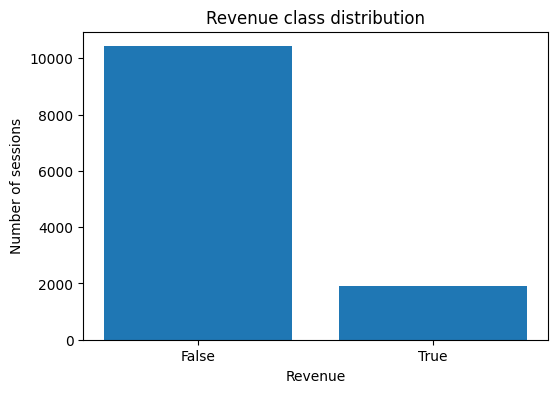

In [10]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

The chart shows a clear class imbalance. Most sessions did not end in a purchase.

Because of this, accuracy on its own will not be enough. I will also use precision, recall, F1-score and a confusion matrix later.

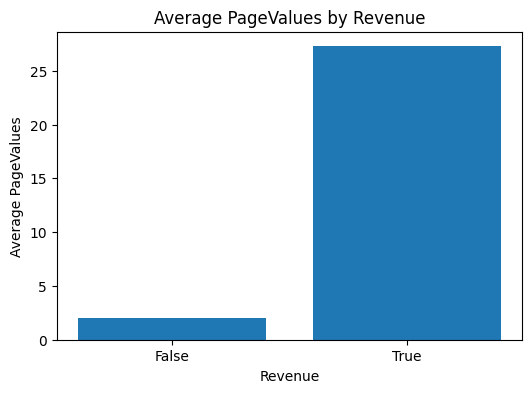

In [11]:
pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()

plt.figure(figsize=(6, 4))
plt.bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
plt.title("Average PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average PageValues")
plt.show()

Purchase sessions have much higher average `PageValues`.

This suggests that `PageValues` may be useful for predicting `Revenue`. I will check this again later when comparing feature importance and model performance.

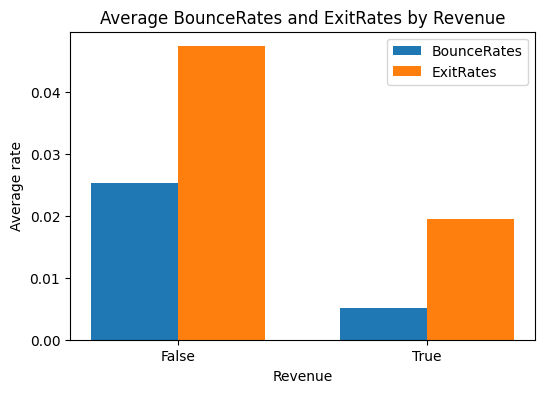

In [12]:
rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()

x = np.arange(len(rate_means.index))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
plt.bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
plt.title("Average BounceRates and ExitRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average rate")
plt.xticks(x, rate_means.index.astype(str))
plt.legend()
plt.show()

Purchase sessions have lower average `BounceRates` and `ExitRates`.

`BounceRates` refers to sessions where a user enters the site and leaves without continuing to other pages. `ExitRates` refers to how often users leave from a particular page. 

Lower values for purchase sessions suggest that users who stay and continue browsing are more likely to buy, so these features may help the models separate purchase and non-purchase sessions.

## Feature and target preparation

In [13]:
# Separate the input features from the target variable
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (12330, 17)
Target data shape: (12330,)


I split the dataset into `X` and `y`. `X` contains the input features, and `y` contains the target variable, `Revenue`.

This gives 17 features for each session and one target value to predict.

In [14]:
# Check the target balance before splitting the data
target_balance = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True) * 100
})

target_balance

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The target balance is checked again before splitting the data.

Because the classes are imbalanced, I will use a stratified train-test split so that the training and test sets keep a similar balance of purchase and non-purchase sessions.

In [15]:
# Set up the column groups for preprocessing
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features.

The categorical list includes text columns, one Boolean value and coded category columns. The remaining columns are treated as numerical browsing-behaviour features.

`Weekend` is included with the categorical features because it describes the type of session rather than measuring a continuous value. Since it simply indicates whether the visit happened on a weekend or not, it makes sense to treat it like the other categorical variables. Similarly, features such as `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are treated as categorical because their numbers are just labels for different groups, not values with a meaningful order.

In [16]:
# Split the data with an 80/20 train/test split
# Stratify keeps the Revenue balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9864, 17)
Test features: (2466, 17)
Training target: (9864,)
Test target: (2466,)


The data is split into training and test sets. The training set will be used to fit the models, while the test set will be kept back for evaluation.

An 80/20 train-test split is used so that most of the dataset is available for model training, while still keeping a separate unseen test set for final evaluation. The split uses `stratify=y` because the target variable is imbalanced, with only about 15.5% of sessions resulting in a purchase. Stratification keeps this class balance similar in both the training and test sets, which makes the evaluation fairer and reduces the chance that the minority purchase class is under-represented in either split.

In [17]:
# Check that the class balance is similar after the split
split_balance = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True) * 100,
    "test_percentage": y_test.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.529603,84.509327
True,15.470397,15.490673


`split_balance` confirms that stratification successfully maintained consistent class proportions between the training and testing sets.

# Preprocessing setup

In [18]:
# Scale numbers and one-hot encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The preprocessor applies different steps to different column types.

The numerical columns are scaled with `StandardScaler`, and the categorical columns are converted with `OneHotEncoder`. This prepares the data for models that need numerical input.

## Feature Selection

The heatmap shows the correlation between the numerical features. Red areas show positive correlations, blue areas show negative correlations, and the diagonal is always strongest because each feature is perfectly correlated with itself.

The clearest relationship with `Revenue` is the positive correlation with `PageValues`. `ExitRates` and `BounceRates` move in the opposite direction, which suggests that sessions with higher exit or bounce behaviour are less likely to end in a purchase. This is only an initial linear check, so it is used as a simple filter view rather than as the final feature selection method.

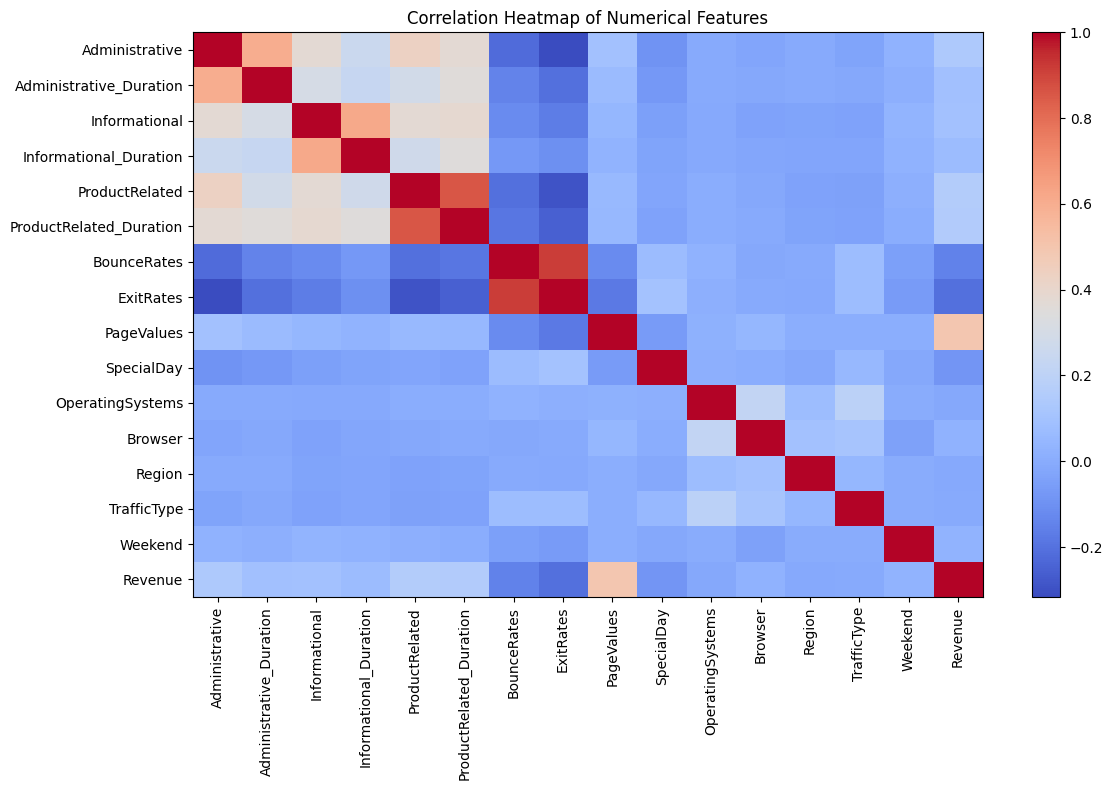

In [20]:
# Create a correlation matrix for the numerical columns
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

The correlation check reinforces that `PageValues` has the strongest positive relationship with `Revenue`, with a correlation of 0.493. `ProductRelated` and `ProductRelated_Duration` are also positively related to purchases, at 0.159 and 0.152.

`ExitRates` and `BounceRates` have negative correlations with `Revenue`, at -0.207 and -0.151. This is consistent with the idea that sessions where users leave quickly are less likely to end in a purchase, although correlation only shows association rather than causation.

Some features, such as `Administrative`, `Informational`, `SpecialDay` and `Informational_Duration`, show weaker direct correlations with `Revenue`. These features may still be useful in combination with others, but their individual linear relationship with the target is weaker. Correlation is therefore used as a simple filter check, while mutual information is used next as a broader feature selection method.

## Feature Selection with Mutual Information

I will use mutual information as a filter-based feature selection method to get an initial idea of how strongly each input feature relates to the target variable. This step will be applied only to the training data so that no information from the test set is used during model development.

This step gives an independent feature-ranking method before the model-based feature importance section later in the notebook.

mutual_info_classif scores each processed feature by how much information it appears to give about the target, Revenue. A higher score means the feature has a stronger relationship with whether the session ended in a purchase.

In [ ]:
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif

# Fit a copy of the preprocessor on the training data only.
# This avoids using the test set when calculating feature selection scores.
mi_preprocessor = clone(preprocessor)

X_train_processed = mi_preprocessor.fit_transform(X_train)
processed_feature_names = mi_preprocessor.get_feature_names_out()

# Mutual information gives a filter-based score for each processed feature.
# The random_state keeps the score calculation reproducible.
mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_df.head(15)

,feature,mutual_information
0,num__PageValues,0.171488
1,num__ExitRates,0.044069
2,num__ProductRelated_Duration,0.037681
3,num__BounceRates,0.029675
4,num__ProductRelated,0.019710
5,num__Administrative_Duration,0.019486
6,num__Administrative,0.014115
7,cat__Month_Nov,0.013364
8,num__SpecialDay,0.008251
9,cat__VisitorType_New_Visitor,0.007232


The mutual information scores suggest that `PageValues` is by far the strongest individual feature, with a score of 0.171488. There is a clear drop after this. The next highest features are `ExitRates` at 0.044069, `ProductRelated_Duration` at 0.037681 and `BounceRates` at 0.029675.

This makes sense for this dataset. `PageValues` is linked to the estimated value of pages visited before a transaction, so it is closely connected to purchase behaviour. The other high-ranking features are also mainly about how users behaved during the session, such as whether they stayed on product pages, left quickly, or exited the site.

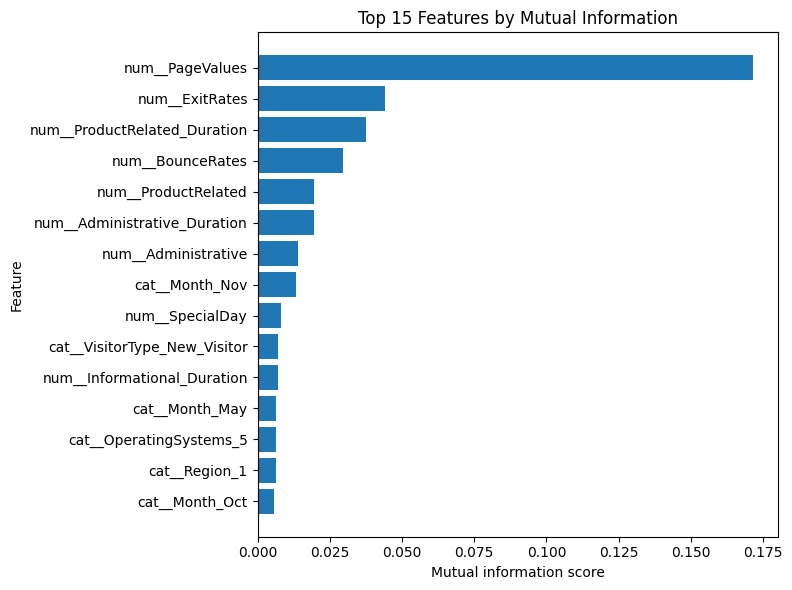

In [ ]:
top_mi_features = mi_scores_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

The chart makes the same pattern easier to see. `PageValues` stands out clearly, while the rest of the features have much smaller mutual information scores.

Most of the top features are numerical browsing-behaviour features, including `ExitRates`, `ProductRelated_Duration`, `BounceRates`, `ProductRelated`, `Administrative_Duration` and `Administrative`. A few one-hot encoded categorical features also appear, such as `Month_Nov`, `VisitorType_New_Visitor`, `Month_May`, `OperatingSystems_5`, `Region_1` and `Month_Oct`.

This suggests that the strongest signal comes from what the visitor actually did during the session. Timing and visitor type still seem useful, but they are not as strong as the direct behavioural features.

In [ ]:
from sklearn.feature_selection import SelectKBest

# Use a wrapper so mutual information is reproducible inside SelectKBest.
def reproducible_mutual_info(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

# Use the top 15 processed features from mutual information.
# This selector is placed inside the pipeline so it is fitted only on the
# training folds during cross-validation.
TOP_K_FEATURES = 15

selected_feature_results = []
selected_feature_pipelines = {}

selected_feature_models = {
    "Logistic Regression selected features": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine selected features": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting selected features": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier selected features": MLPClassifier(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
}

for model_name, model in selected_feature_models.items():
    selected_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(
            score_func=reproducible_mutual_info,
            k=TOP_K_FEATURES
        )),
        ("model", model)
    ])

    selected_pipeline.fit(X_train, y_train)
    y_pred_selected = selected_pipeline.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred_selected),
        "precision": precision_score(y_test, y_pred_selected, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred_selected, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred_selected, pos_label=True, zero_division=0)
    }

    selected_feature_results.append(results)
    selected_feature_pipelines[model_name] = selected_pipeline

selected_feature_results_df = pd.DataFrame(selected_feature_results)
selected_feature_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
3,MLPClassifier selected features,0.897405,0.704762,0.581152,0.637016
2,Hist Gradient Boosting selected features,0.895783,0.699681,0.573298,0.630216
1,Support Vector Machine selected features,0.857664,0.528440,0.753927,0.621359
0,Logistic Regression selected features,0.857259,0.527778,0.746073,0.618221


The selected-feature models give mixed results. `MLPClassifier` has the highest F1-score on this selected feature set, at 0.637016, with accuracy of 0.897405, precision of 0.704762 and recall of 0.581152. `Hist Gradient Boosting` is close behind, with an F1-score of 0.630216.

`Support Vector Machine` has the highest recall, at 0.753927, meaning it identifies more of the purchase sessions. However, its precision is much lower, at 0.528440, so it also creates more false purchase predictions. `Logistic Regression` follows a similar pattern, with recall of 0.746073 and precision of 0.527778.

At this stage, the selected-feature models are useful as a simplification experiment. They perform reasonably, but they do not clearly beat the strongest full-feature baseline results, so I will continue with the full feature set for the main tuning stage.

In [ ]:
# Inspect the fitted selector from one selected-feature pipeline.
# The selected feature list should be the same because the selector uses the same training data.
selected_pipeline = selected_feature_pipelines["Hist Gradient Boosting selected features"]

processed_feature_names = (
    selected_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

selected_mask = (
    selected_pipeline
    .named_steps["feature_selection"]
    .get_support()
)

selected_features_df = pd.DataFrame({
    "selected_feature": processed_feature_names[selected_mask]
})

selected_features_df

,selected_feature
0,num__Administrative
1,num__Administrative_Duration
2,num__Informational_Duration
3,num__ProductRelated
4,num__ProductRelated_Duration
5,num__BounceRates
6,num__ExitRates
7,num__PageValues
8,num__SpecialDay
9,cat__Month_May


The selected feature list confirms that `SelectKBest` kept a mixture of numerical behavioural features and a small number of one-hot encoded categorical features. The selected numerical features include page counts, durations, `BounceRates`, `ExitRates`, `PageValues` and `SpecialDay`. The selected categorical features are `Month_May`, `Month_Nov`, `Month_Oct`, `VisitorType_New_Visitor`, `OperatingSystems_5` and `Region_1`.

This is useful because it shows exactly what the selected-feature experiment used after preprocessing. It also shows that the selector did not only keep the highest raw numerical columns. Some categorical categories were retained as well, but the main selected features are still the session-behaviour variables.

## Candidate Machine Learning Models

This project uses supervised machine learning because the dataset contains labelled examples. Each session has a known target value, `Revenue`, showing whether the session ended in a purchase. The task is therefore a binary classification problem.

Several candidate classification algorithms are tested so that different modelling approaches can be compared. `Logistic Regression` is included as an interpretable linear baseline. `Decision Tree` and `Random Forest` are included because tree-based models can capture non-linear relationships and interactions between features. `Gradient Boosting` and `Hist Gradient Boosting` are included because boosting methods often perform well on structured tabular datasets. `Support Vector Machine` is included because it can work well for classification after scaling. `K-Nearest Neighbours` is included as a distance-based baseline, while `MLPClassifier` is included as a neural network comparison.

This gives a mix of linear, tree-based, ensemble, distance-based, kernel-based and neural network methods. Comparing these models helps avoid choosing a final model based on one modelling assumption only.

## Baseline model comparison

I will now try several baseline classification models using the same train-test split and the same preprocessing steps.

Because the target is imbalanced, accuracy could be misleading. I will still record accuracy, but I will focus more on F1-score, recall, precision and the confusion matrix.

The baseline models are first trained using default or lightly adjusted settings. This gives an initial comparison before tuning. For models that support it cleanly, `class_weight="balanced"` is used because the target variable is imbalanced and only about 15.5% of sessions resulted in a purchase. The main comparison metric is F1-score, because it balances precision and recall and is more informative than accuracy alone for this imbalanced classification task.

In [ ]:
# Baseline models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier": MLPClassifier(
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

`class_weight="balanced"` is used for models where it works well, such as Logistic Regression, Decision Tree, Random Forest, and SVM. It helps the model pay more attention to the smaller purchase class by giving it extra weight. Since not all models handle this setting in the same way, class imbalance is also addressed through stratified splitting and by focusing on F1-score, precision, and recall instead of accuracy alone.

In [ ]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Put the same preprocessing in front of every model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train on the training data only
    pipeline.fit(X_train, y_train)
    
    # Predict on the test data
    y_pred = pipeline.predict(X_test)
    
    # Store the main scores
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, pipeline

In [ ]:
baseline_results = []
trained_pipelines = {}

for model_name, model in models.items():
    results, pipeline = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline


Logistic Regression
Confusion matrix:
[[1790  294]
 [  98  284]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.86      0.90      2084
        True       0.49      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466


Decision Tree
Confusion matrix:
[[1899  185]
 [ 183  199]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.91      0.91      2084
        True       0.52      0.52      0.52       382

    accuracy                           0.85      2466
   macro avg       0.72      0.72      0.72      2466
weighted avg       0.85      0.85      0.85      2466


Random Forest
Confusion matrix:
[[2031   53]
 [ 207  175]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.899027,0.709779,0.589005,0.643777
6,Hist Gradient Boosting,0.897810,0.708333,0.578534,0.636888
4,Support Vector Machine,0.865369,0.547710,0.751309,0.633554
0,Logistic Regression,0.841038,0.491349,0.743455,0.591667
2,Random Forest,0.894566,0.767544,0.458115,0.573770
7,MLPClassifier,0.869424,0.585227,0.539267,0.561308
1,Decision Tree,0.850770,0.518229,0.520942,0.519582
3,K-Nearest Neighbours,0.876723,0.682243,0.382199,0.489933


The baseline comparison shows that the models behave quite differently on the purchase class.

Gradient Boosting has the best F1-score for the True class, at about 0.64, and the highest accuracy at about 0.90. Its precision is about 0.71 and recall is about 0.59, so it gives the strongest overall balance in the baseline comparison.

Hist Gradient Boosting performs almost the same as Gradient Boosting, with accuracy of 0.898 and an F1-score of 0.637 for the True class. Its precision is 0.708 and recall is 0.579. This shows that the histogram-based version is a useful alternative, but in this baseline test it does not quite improve on the standard Gradient Boosting model.

Support Vector Machine has the highest recall for the purchase class, at about 0.75, which means it finds the most actual purchase sessions. However, its precision is lower than Gradient Boosting, so it also makes more false purchase predictions.

Random Forest has the highest precision for the purchase class, at about 0.76, but recall is much lower at about 0.46. This means it gives fewer false purchase predictions, but misses more real purchases.

Logistic Regression remains a useful baseline due to its good recall, but its precision is lower. Decision Tree and K-Nearest Neighbours are weaker overall on F1-score. MLPClassifier performs reasonably, but it gives a convergence warning, so it needs more tuning before being judged properly.

Based on this first comparison, Gradient Boosting, Hist Gradient Boosting, Support Vector Machine, Random Forest and Logistic Regression look most worth continuing with. Gradient Boosting has the best F1-score, Hist Gradient Boosting gives a very similar result and may be faster to tune, SVM and Logistic Regression have strong recall, and Random Forest has strong precision.
MLPClassifier gives a reasonable result. Although its baseline result did not outperform the best classical models and it produced a convergence warning, it is still useful as a comparison because neural networks are a different model family. This allows the project to compare linear, kernel-based, tree-based ensemble and neural network approaches.

## Feature Importance Analysis

Feature importance is checked before tuning because it helps show which inputs the strongest baseline model relies on most.

This can help decide whether a smaller feature set is worth testing later. However, features should not be removed automatically just because they have lower importance, as weaker individual features may still be useful when combined with others.

The feature importance plot is based on `Gradient Boosting`, which was the strongest baseline model by F1-score. This gives a clearer view of which features are contributing most to the model’s predictions.

In [ ]:
# Get the trained Gradient Boosting pipeline
gb_pipeline = trained_pipelines["Gradient Boosting"]

# Get the fitted model and the fitted preprocessor
gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]

# Get the feature names after preprocessing
feature_names = gb_preprocessor.get_feature_names_out()

# Match each feature name with its importance score
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.761713
6,num__BounceRates,0.039870
17,cat__Month_Nov,0.037841
0,num__Administrative,0.031076
7,num__ExitRates,0.029149
5,num__ProductRelated_Duration,0.027551
4,num__ProductRelated,0.023125
1,num__Administrative_Duration,0.011746
16,cat__Month_May,0.008686
3,num__Informational_Duration,0.004775


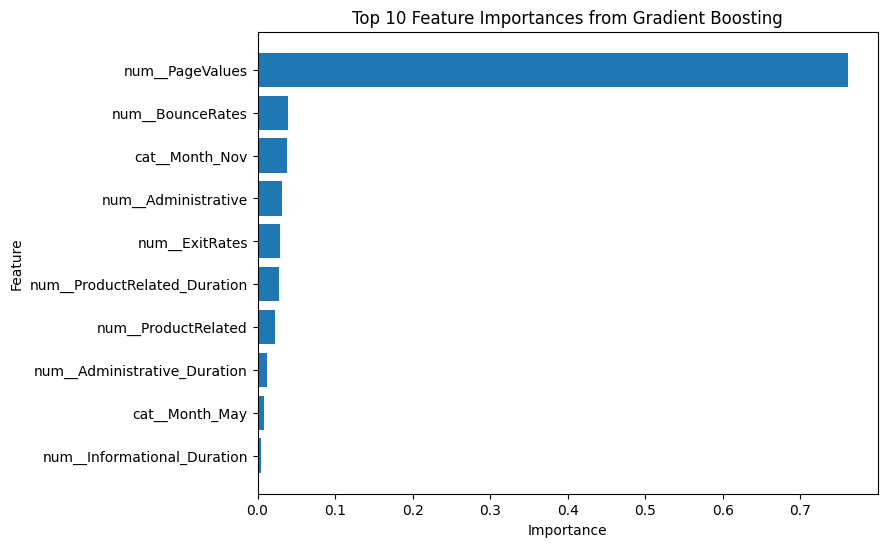

In [ ]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows that `PageValues` is by far the strongest feature in the Gradient Boosting model.

After `PageValues`, the next most important features are `BounceRates`, `Month_Nov`, `Administrative`, `ExitRates`, `ProductRelated_Duration` and `ProductRelated`. This partly supports the earlier analysis, because `BounceRates`, `ExitRates` and product-related activity all relate to how users move through the website.

`Month_Nov` being important may make sense because online shopping behaviour can change by month, especially around seasonal shopping periods. `Administrative` is also useful to note because it suggests that non-product browsing activity may still contain some signal.

One thing to note is that `PageValues` dominates the plot. I will keep it in the model because it is part of the dataset, but I should mention in the report that the model relies heavily on this feature.

## Testing Model Dependence on PageValues

The feature importance results showed that `PageValues` was by far the strongest feature in the `Gradient Boosting` model. This may be useful for prediction, but it also means the model may depend heavily on one feature. 

To test this, I will train another `Gradient Boosting` model without `PageValues` and compare the results with the original model.

In [ ]:
# Create a new feature set without PageValues
X_no_pagevalues = X.drop("PageValues", axis=1)

# Update feature groups
numerical_features_no_pagevalues = [
    col for col in numerical_features if col != "PageValues"
]

categorical_features_no_pagevalues = categorical_features.copy()

# Split the data again using the same settings
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_no_pagevalues,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Create preprocessing for the reduced feature set
preprocessor_no_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_no_pagevalues),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_no_pagevalues)
    ]
)

# Build the pipeline manually because this experiment uses a different preprocessor
gb_no_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_no_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Train on the reduced feature set
gb_no_pagevalues_pipeline.fit(X_train_np, y_train_np)

# Predict on the test data
y_pred_np = gb_no_pagevalues_pipeline.predict(X_test_np)

# Store the main scores
gb_no_pagevalues_results = {
    "model": "Gradient Boosting without PageValues",
    "accuracy": accuracy_score(y_test_np, y_pred_np),
    "precision": precision_score(y_test_np, y_pred_np, pos_label=True, zero_division=0),
    "recall": recall_score(y_test_np, y_pred_np, pos_label=True, zero_division=0),
    "f1": f1_score(y_test_np, y_pred_np, pos_label=True, zero_division=0)
}

print("\nGradient Boosting without PageValues")
print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred_np))

print("\nClassification report:")
print(classification_report(y_test_np, y_pred_np, zero_division=0))

gb_no_pagevalues_results


Gradient Boosting without PageValues
Confusion matrix:
[[2052   32]
 [ 356   26]]

Classification report:
              precision    recall  f1-score   support

       False       0.85      0.98      0.91      2084
        True       0.45      0.07      0.12       382

    accuracy                           0.84      2466
   macro avg       0.65      0.53      0.52      2466
weighted avg       0.79      0.84      0.79      2466



{'model': 'Gradient Boosting without PageValues',
 'accuracy': 0.8426601784266018,
 'precision': 0.4482758620689655,
 'recall': 0.06806282722513089,
 'f1': 0.11818181818181818}

Removing `PageValues` caused a major drop in performance for the purchase class. The original `Gradient Boosting` model had an F1-score of 0.644 for `Revenue=True`, but without `PageValues` this dropped to 0.118. Recall for purchase sessions also fell dramatically to 0.068, as the model only identified 26 out of 382 actual purchase sessions.

The confusion matrix shows that the model became very conservative after removing `PageValues`. It correctly predicted most non-purchase sessions, with 2052 true negatives and only 32 false positives, but it missed 356 purchase sessions. This means the model still achieved 0.843 accuracy, but that seemingly high accuracy is misleading because the dataset is imbalanced and the model performs poorly on the minority purchase class.

This testing confirms that `PageValues` is a very strong predictor for this dataset. It should be kept in the final model, but the report should mention that the model depends heavily on this feature.

## Model Tuning and Refinement

After comparing the baseline models, the strongest or most informative candidates are tuned. Tuning is focused on models that either achieved strong baseline F1-score or showed a useful precision-recall trade-off. `Gradient Boosting` and `Hist Gradient Boosting` are tuned because they had the strongest baseline F1-scores. `Support Vector Machine` is tuned because it achieved high recall. `Logistic Regression` is tuned lightly because it provides an interpretable comparison model. `MLPClassifier` is also tuned because it gives a neural network comparison, but its settings need refinement due to the convergence warning.

`RandomizedSearchCV` is used for tuning rather than a full grid search. This is a practical choice because several models and parameter combinations are being tested, and random search can explore useful configurations with lower runtime than testing every possible combination. The searches use 5-fold cross-validation on the training data and `scoring="f1"` so that each configuration is compared using a metric that reflects both precision and recall.

## Tuning Gradient Boosting

I will tune `Gradient Boosting` first because it has the best baseline F1-score for the purchase class. I will use a small parameter search rather than a very large grid, so that the tuning process will be manageable and can run locally. The search will use F1-score as the main scoring metric for the reasons explained above.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

"""
I chose these parameters because they control the main ways a Gradient Boosting model can become more or less complex. 
`n_estimators` and `learning_rate` control how many boosting stages are used and how strongly each stage affects the final model. 
`max_depth` controls how complex each individual tree can be, while `min_samples_leaf` can help reduce overfitting by stopping leaves from
becoming too small. I used a small search space first so that tuning stayed manageable and could be expanded later if needed [2].
[2] Scikit-learn developers, “GradientBoostingClassifier,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html. [Accessed: 3-Jun-2026].
"""
gb_param_grid = {
    # Number of boosting stages to build
    "model__n_estimators": [100, 200],
    # Controls how strongly each new tree contributes
    # Scikit-learn notes a trade-off between learning_rate and n_estimators [2]
    "model__learning_rate": [0.05, 0.1],
    # Controls the depth of each individual tree
    "model__max_depth": [2, 3],
    # A slightly higher value can smooth the model and reduce overfitting
    "model__min_samples_leaf": [1, 2]
}

# RandomizedSearchCV tests a limited number of parameter combinations using cross-validation, rather than exhaustively testing every combination [3].
# [3] Scikit-learn developers, “RandomizedSearchCV,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html. [Accessed: 3-Jun-2026].
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the search on the training data only
gb_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best cross-validation F1-score:
0.6614963923916196


In [ ]:
gb_tuned_pred = gb_search.predict(X_test)

gb_tuned_results = {
    "model": "Tuned Gradient Boosting",
    "accuracy": accuracy_score(y_test, gb_tuned_pred),
    "precision": precision_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, gb_tuned_pred, pos_label=True, zero_division=0)
}

print("\nTuned Gradient Boosting")
print("Confusion matrix:")
print(confusion_matrix(y_test, gb_tuned_pred))

print("\nClassification report:")
print(classification_report(y_test, gb_tuned_pred, zero_division=0))

gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1995   89]
 [ 157  225]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.72      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.90      2466



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9002433090024331,
 'precision': 0.7165605095541401,
 'recall': 0.5890052356020943,
 'f1': 0.646551724137931}

The tuned `Gradient Boosting` model selected 100 boosting stages, a minimum leaf size of 2, a maximum tree depth of 3 and a learning rate of 0.1. This is quite close to the default model, but with a slightly higher `min_samples_leaf`, which can help reduce overfitting by stopping very small leaf nodes.

The tuned model gave a small improvement over the original baseline `Gradient Boosting` result. The baseline model had an F1-score of 0.644 for the `Revenue=True` class, while the tuned model achieved about 0.647. Recall stayed the same at 0.589, meaning it still correctly identified 225 out of 382 purchase sessions. Precision improved slightly from 0.710 to about 0.717, because the tuned model made fewer false purchase predictions.

The confusion matrix shows 1995 true negatives, 89 false positives, 157 false negatives and 225 true positives. Overall, this tuning step produced only a small improvement, but it shows that a slightly more regularised version of `Gradient Boosting` can reduce false positives while keeping the same purchase recall.

## Tuning Hist Gradient Boosting

`Hist Gradient Boosting` was tuned next because its baseline result was very close to the standard `Gradient Boosting` model. Since it uses a histogram-based version of gradient boosting, it may be efficient to tune while still keeping similar predictive behaviour. A small parameter search was used first so that the tuning process stayed manageable.

In [ ]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

"""
I tuned Hist Gradient Boosting after the standard Gradient Boosting model because its baseline result was very similar.
I chose a small set of parameters that control the main parts of the model: how many boosting iterations are used,
how strongly each iteration contributes, how complex the trees can become, and whether regularisation is applied.

`max_iter` controls the number of boosting iterations, `learning_rate` controls the contribution of each boosting step,
`max_leaf_nodes` limits the size of each tree, and `l2_regularization` penalises more complex leaf values [4].

[4] Scikit-learn developers, “HistGradientBoostingClassifier,” Scikit-learn documentation. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html. [Accessed: 3-Jun-2026].
"""
hgb_param_grid = {
    # Number of boosting iterations (imilar to the number of trees for binary classification)
    "model__max_iter": [100, 200],
    # Lower learning rates make the model learn more gradually
    "model__learning_rate": [0.05, 0.1],
    # Controls tree complexity by limiting the number of leaf nodes in each tree
    "model__max_leaf_nodes": [15, 31],
    # Adds regularisation. 0 for default, 0.1 adds a small penalty
    "model__l2_regularization": [0, 0.1]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 31, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
Best cross-validation F1-score:
0.6675528704733228


The search chose a smaller, more cautious model. It used the default number of boosting iterations, a lower learning rate, fewer leaf nodes than the default, and no extra L2 regularisation. So the best version was not actually “bigger and more complex”, rather it was more controlled.

In [ ]:
hgb_tuned_pred = hgb_search.predict(X_test)

hgb_tuned_results = {
    "model": "Tuned Hist Gradient Boosting",
    "accuracy": accuracy_score(y_test, hgb_tuned_pred),
    "precision": precision_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, hgb_tuned_pred, pos_label=True, zero_division=0)
}

print("\nTuned Hist Gradient Boosting")
print("Confusion matrix:")
print(confusion_matrix(y_test, hgb_tuned_pred))

print("\nClassification report:")
print(classification_report(y_test, hgb_tuned_pred, zero_division=0))

hgb_tuned_results


Tuned Hist Gradient Boosting
Confusion matrix:
[[1999   85]
 [ 153  229]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.73      0.60      0.66       382

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.90      0.90      2466



{'model': 'Tuned Hist Gradient Boosting',
 'accuracy': 0.9034874290348743,
 'precision': 0.7292993630573248,
 'recall': 0.599476439790576,
 'f1': 0.6580459770114943}

In [ ]:
tuned_results = [
    gb_tuned_results,
    hgb_tuned_results
]

The tuned `Hist Gradient Boosting` model selected a learning rate of 0.05, 100 boosting iterations, 31 maximum leaf nodes and no L2 regularisation. The lower learning rate means the model learns more gradually, while 100 iterations and 31 leaf nodes are close to the default model settings.

This tuning step improved the model compared with the baseline `Hist Gradient Boosting` result. The F1-score for the `Revenue=True` class increased from 0.637 to about 0.658. Precision increased from 0.708 to 0.729, and recall increased from 0.579 to 0.599. This means the tuned model is both more reliable when it predicts a purchase and slightly better at finding actual purchase sessions.

The confusion matrix shows that the tuned model correctly identified 229 purchase sessions and missed 153. It also made 85 false purchase predictions. Compared with the baseline version, this is a better balance between precision and recall for the purchase class.

`Tuned Hist Gradient Boosting` is now the strongest model so far. It has the best F1-score for the purchase class and one of the strongest overall accuracy scores. My next step will be to tune `Support Vector Machine`, which comes from a different model family, to check whether a kernel-based model can produce a better recall or F1-score trade-off.

In [ ]:
def evaluate_tuned_model(search, model_name, X_test, y_test):
    y_pred = search.predict(X_test)
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Best parameters:")
    print(search.best_params_)
    print("\nBest CV F1-score:")
    print(search.best_score_)
    
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results

Next steps:

Tune SVM

Tune Logistic Regression

Tune Random Forest

Tune MLPClassifier (The baseline MLPClassifier produces a convergence warning, meaning the optimiser hasn't fully converged within the original iteration limit. To refine the model, the tuned version should increase max iterations and maybe use early stopping=true. This will hopefully give the model more opportunity to learn whilst reducing the risk of unnecessary training in the cases that the validation performance stops improving.)

## Tuning Support Vector Machine

`Support Vector Machine` is tuned because it had the highest baseline recall for the purchase class. This means it identified the largest proportion of actual purchase sessions, although its precision was lower than the boosting models. The aim of tuning is therefore to check whether SVM can keep its useful recall while improving the overall F1-score.

The tuning search compares a `linear` kernel with an `rbf` kernel. Scikit-learn explains that SVC models try to find a separating hyperplane by maximising the margin between classes, with `C` controlling the amount of regularisation and tolerance for misclassification [7]. A linear kernel is included because it tests whether a simpler straight boundary is sufficient. An `rbf` kernel is also included because scikit-learn explains that non-linear kernels can be used when the data is not linearly separable, and that the RBF kernel is the default SVM kernel in scikit-learn [7].

The search tunes `C` for both kernels and tunes `gamma` only for the `rbf` kernel. This is because scikit-learn notes that `gamma` is ignored for the linear kernel, but for non-linear kernels it controls the influence of individual training samples on the decision boundary [7]. `class_weight` is also included in the search because the target variable is imbalanced. This allows the tuning process to test whether weighting the minority purchase class improves F1-score or whether it reduces precision too much.

[7] Scikit-learn developers, “Plot classification boundaries with different SVM Kernels,” scikit-learn documentation. Available: https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html

In [ ]:
# Keep preprocessing inside the pipeline so scaling and encoding are applied consistently
svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=RANDOM_STATE))
])

# Test both a simple linear boundary and a non-linear RBF boundary
svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        # tuning class weighting because the purchase class is imbalanced
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=12,
    # using F1 because it balances precision and recall for the minority class.
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

svm_tuned_results = evaluate_tuned_model(
    svm_search,
    "Tuned Support Vector Machine",
    X_test,
    y_test
)

tuned_results.append(svm_tuned_results)


Tuned Support Vector Machine
Best parameters:
{'model__kernel': 'linear', 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6551009164529351

Confusion matrix:
[[1862  222]
 [ 104  278]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2084
        True       0.56      0.73      0.63       382

    accuracy                           0.87      2466
   macro avg       0.75      0.81      0.77      2466
weighted avg       0.89      0.87      0.87      2466



The tuned `Support Vector Machine` selected a `linear` kernel with `class_weight="balanced"` and `C=10`. This suggests that, for this processed dataset, the simpler linear SVM performed better than the tested RBF options.

The model achieved precision `0.56`, recall `0.73` and F1-score `0.63` for the purchase class. This confirms the same pattern seen in the baseline SVM: the model is good at identifying a relatively high proportion of actual purchase sessions, but it also produces more false positives than the boosting models. The confusion matrix shows that it correctly identified `278` purchase sessions, but missed `104` and incorrectly classified `222` non-purchase sessions as purchases.

Overall, tuning did not produce a major improvement over the baseline SVM. The tuned SVM remains useful as a high-recall comparison model, but at this stage it seems unlikely to be the final chosen model unless I decide that recall should be considered more important than precision.

## Tuning Logistic Regression

`Logistic Regression` is tuned as the main interpretable linear comparison model. It is suitable for this task because the target variable, `Revenue`, is binary, and scikit-learn implements logistic regression as a classifier for categorical targets by converting predicted probabilities into class predictions.

The tuning search is kept small because the model is relatively simple compared with the ensemble models. The search focuses on `C` and `l1_ratio`. `C` controls the inverse strength of regularisation, so smaller values apply stronger regularisation and larger values allow the model to fit the training data more closely. In this scikit-learn version, `l1_ratio=0` is used for L2 regularisation and `l1_ratio=1` is used for L1 regularisation. This allows the search to compare standard L2 regularisation with L1 regularisation, which can produce a sparser model by reducing less useful coefficients [8].

[8] Scikit-learn developers, “Logistic regression,” scikit-learn documentation. Available: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

In [ ]:
# Logistic Regression is here because it is a highly interpretable linear comparison model
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="liblinear"
    ))
])

# liblinear supports both l1 and l2 penalties, so both are tested
# l1_ratio=0 is equivalent to L2, and l1_ratio=1 is equivalent to L1.
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0, 1]
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

logreg_search.fit(X_train, y_train)

logreg_tuned_results = evaluate_tuned_model(
    logreg_search,
    "Tuned Logistic Regression",
    X_test,
    y_test
)

tuned_results.append(logreg_tuned_results)


Tuned Logistic Regression
Best parameters:
{'model__l1_ratio': 1, 'model__C': 0.01}

Best CV F1-score:
0.6540274740091607

Confusion matrix:
[[1870  214]
 [ 104  278]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.90      0.92      2084
        True       0.57      0.73      0.64       382

    accuracy                           0.87      2466
   macro avg       0.76      0.81      0.78      2466
weighted avg       0.89      0.87      0.88      2466



The tuned `Logistic Regression` model selected `C=0.01` and `l1_ratio=1`. This means the best model used strong regularisation with the L1-style option, suggesting that a simpler linear model worked better than a less restricted version.

For the purchase class, the tuned model achieved precision `0.57`, recall `0.73` and F1-score `0.64`. The confusion matrix shows that it correctly identified `278` purchase sessions and missed `104`, while incorrectly classifying `214` non-purchase sessions as purchases. This result is very close to the tuned `Support Vector Machine`, but with slightly higher precision and F1-score.

While `Logistic Regression` is unlikely to be the strongest final model, it acts as an simple and interpretable comparison model with decent recall.

## Tuning Random Forest

`Random Forest` is tuned because the baseline model had the strongest precision for the purchase class, but weaker recall. It was reliable when it predicted purchases, but missed too many actual purchase sessions.

Tuning checks if changing the number of trees, feature sampling and tree complexity can improve recall and F1-score without losing too much precision. This fits the way Random Forests work, the way that they reduce the variance of individual decision trees by combining trees built from random samples and random feature subsets [9].

In [ ]:
# Random Forest is tuned because it had the strongest baseline precision.
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

# Tune tree count, feature sampling and tree complexity.
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_tuned_results = evaluate_tuned_model(
    rf_search,
    "Tuned Random Forest",
    X_test,
    y_test
)

tuned_results.append(rf_tuned_results)


Tuned Random Forest
Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6874584426674291

Confusion matrix:
[[1947  137]
 [ 127  255]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.93      0.94      2084
        True       0.65      0.67      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.80      0.80      2466
weighted avg       0.89      0.89      0.89      2466



The tuned `Random Forest` selected `100` trees, `min_samples_leaf=2`, `max_features="sqrt"`, unrestricted tree depth and `class_weight="balanced"`. This suggests that the model benefited from using random feature subsets and slightly restricted leaf sizes, while still allowing the trees to grow deeply.

For the purchase class, the tuned model achieved precision `0.65`, recall `0.67` and F1-score `0.66`. The confusion matrix shows that it correctly identified `255` purchase sessions and missed `127`, while incorrectly classifying `137` non-purchase sessions as purchases.

Compared with the baseline `Random Forest`, the tuned model gave up some precision but improved recall substantially. The baseline model was too cautious and missed many actual purchase sessions. The tuned version improved and currently performs better than the tuned `Support Vector Machine` and tuned `Logistic Regression` on F1-score.


## Tuning MLPClassifier

`MLPClassifier` is tuned as a neural network comparison. The baseline model produced a convergence warning, so the tuned version increases `max_iter` and uses `early_stopping=True`. The search also tests hidden layer size, activation function, regularisation strength and learning rate, because these affect how the network learns from the processed features.

In [ ]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        # Increase max_iter because the baseline MLP did not fully converge
        max_iter=1000,
        # Use early stopping so training can stop if validation performance stops improving
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

mlp_param_grid = {
    # Tune network size, activation, regularisation and learning rate.
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__activation": ["relu", "tanh"]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

mlp_search.fit(X_train, y_train)

mlp_tuned_results = evaluate_tuned_model(
    mlp_search,
    "Tuned MLPClassifier",
    X_test,
    y_test
)

tuned_results.append(mlp_tuned_results)


Tuned MLPClassifier
Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.01, 'model__activation': 'tanh'}

Best CV F1-score:
0.6284195544272613

Confusion matrix:
[[1977  107]
 [ 172  210]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.95      0.93      2084
        True       0.66      0.55      0.60       382

    accuracy                           0.89      2466
   macro avg       0.79      0.75      0.77      2466
weighted avg       0.88      0.89      0.88      2466



The tuned `MLPClassifier` chose quite a small network: one hidden layer with `50` neurons, `tanh` activation, `alpha=0.01` and `learning_rate_init=0.01`. Its best cross-validation F1-score was `0.6284195544272613`.

On the test set, the purchase-class precision was `0.66`, recall was `0.55` and F1-score was `0.60`. It correctly predicted `210` purchase sessions, but missed `172`, so the main weakness is recall. Compared with the tuned `Random Forest`, `SVM` and `Logistic Regression`, the MLP found fewer of the actual purchase sessions.

This was still a useful comparison because it showed that a neural network did not automatically perform better on this structured tabular dataset. The stronger results came from the tuned tree-based and linear models.

In [ ]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
4,Tuned Random Forest,0.892944,0.650510,0.667539,0.658915
1,Tuned Hist Gradient Boosting,0.903487,0.729299,0.599476,0.658046
0,Tuned Gradient Boosting,0.900243,0.716561,0.589005,0.646552
3,Tuned Logistic Regression,0.871046,0.565041,0.727749,0.636156
2,Tuned Support Vector Machine,0.867802,0.556000,0.727749,0.630385
5,Tuned MLPClassifier,0.886861,0.662461,0.549738,0.600858


In [ ]:
tuned_results_df.sort_values(by="f1", ascending=False).to_csv(
    "../outputs/tuned_results_original_features.csv",
    index=False
)

## Second modelling cycle: feature engineering

The first tuning cycle used the original feature set. The strongest two models were `Tuned Random Forest` and `Tuned Hist Gradient Boosting`, with almost identical F1-scores. `Random Forest` gave better recall for purchase sessions, while `Hist Gradient Boosting` gave higher precision and accuracy.

This second cycle tests whether a small number of engineered behavioural features improves the model. The aim is not to add many features, but to test a controlled refinement based on the dataset structure and earlier findings.

These engineered features are deliberately tested as a modelling experiment rather than assumed to be an improvement. They partly overlap with the original page-count and duration variables, but they may help by giving the models a compact summary of session size and product focus. The final comparison will decide whether this extra representation improves performance enough to justify keeping it.

In [ ]:
df_engineered = df.copy()

df_engineered["total_pages"] = (
    df_engineered["Administrative"]
    + df_engineered["Informational"]
    + df_engineered["ProductRelated"]
)

df_engineered["total_duration"] = (
    df_engineered["Administrative_Duration"]
    + df_engineered["Informational_Duration"]
    + df_engineered["ProductRelated_Duration"]
)

df_engineered["product_page_ratio"] = np.where(
    df_engineered["total_pages"] > 0,
    df_engineered["ProductRelated"] / df_engineered["total_pages"],
    0
)

df_engineered["product_duration_ratio"] = np.where(
    df_engineered["total_duration"] > 0,
    df_engineered["ProductRelated_Duration"] / df_engineered["total_duration"],
    0
)

df_engineered[
    [
        "total_pages",
        "total_duration",
        "product_page_ratio",
        "product_duration_ratio"
    ]
].describe()

,total_pages,total_duration,product_page_ratio,product_duration_ratio
count,12330.000000,12330.000000,12330.000000,12330.000000
mean,34.550203,1310.037228,0.905098,0.842805
std,46.514053,2037.801702,0.141883,0.268461
min,0.000000,0.000000,0.000000,0.000000
25%,8.000000,222.000000,0.860465,0.823594
50%,20.000000,680.000000,0.963359,0.966939
75%,42.000000,1626.908333,1.000000,1.000000
max,746.000000,69921.647230,1.000000,1.000000


The engineered features were created successfully for all 12,330 sessions.

`total_pages` and `total_duration` are both skewed. One can see that the median session has 20 pages and lasts 680 seconds, whereas the means are much higher at 34.55 pages and 1310.04 seconds, because some sessions are much larger.

The ratio features show that most sessions are strongly product-focused. The median `product_page_ratio` is 0.963359 and the median `product_duration_ratio` is 0.966939. This makes them appear to be worth testing, as they summarise both the session size and product focus.

### Checking the engineered features

In [ ]:
df_engineered[
    [
        "Administrative",
        "Informational",
        "ProductRelated",
        "total_pages",
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "total_duration",
        "product_page_ratio",
        "product_duration_ratio"
    ]
].head(10)

,Administrative,Informational,ProductRelated,total_pages,Administrative_Duration,Informational_Duration,ProductRelated_Duration,total_duration,product_page_ratio,product_duration_ratio
0,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
1,0,0,2,2,0.0,0.0,64.000000,64.000000,1.0,1.0
2,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
3,0,0,2,2,0.0,0.0,2.666667,2.666667,1.0,1.0
4,0,0,10,10,0.0,0.0,627.500000,627.500000,1.0,1.0
5,0,0,19,19,0.0,0.0,154.216667,154.216667,1.0,1.0
6,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
7,1,0,0,1,0.0,0.0,0.000000,0.000000,0.0,0.0
8,0,0,2,2,0.0,0.0,37.000000,37.000000,1.0,1.0
9,0,0,3,3,0.0,0.0,738.000000,738.000000,1.0,1.0


The preview shows that the engineered features have been added as intended. `total_pages` is the sum of the three page-count columns, and `total_duration` is the sum of the three duration columns.

The ratio columns also behave as expected. For example, where all pages are product pages, `product_page_ratio` is 1.0. Where there is no recorded duration, the duration ratio is set to 0 rather than causing a division error.

### Recreating the feature and target sets

The next step is to rebuild `X` and `y` from `df_engineered`. This is needed because the modelling pipeline now needs to include the four new engineered features as part of the input data.

In [ ]:
X = df_engineered.drop(columns=["Revenue"])
y = df_engineered["Revenue"]

categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'total_pages', 'total_duration', 'product_page_ratio', 'product_duration_ratio']


The feature lists show that the same seven categorical features are being treated as categories. The numerical feature list now includes the original numerical columns as well as the four engineered features: `total_pages`, `total_duration`, `product_page_ratio` and `product_duration_ratio`.

This means the new features will be scaled with the other numerical features, while the categorical columns will still be one-hot encoded.

### Train-test split with engineered features

The train-test split is now repeated using the engineered feature set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9864, 21)
Test features: (2466, 21)
Training target: (9864,)
Test target: (2466,)


The split keeps the same 80/20 structure as before. The training set has 9,864 rows and the test set has 2,466 rows.

There are now 21 input features instead of 17, because the four engineered features have been added. Keeping the same split settings makes the second modelling cycle easier to compare with the original feature cycle.

### Rebuilding the preprocessing pipeline

The preprocessing pipeline is rebuilt so that it uses the updated feature lists.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay', 'total_pages', 'total_duration',
                                  'product_page_ratio',
                                  'product_duration_ratio']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The updated preprocessor now includes the four engineered features in the numerical pipeline. These will be standardised along with the other numerical columns.

The categorical pipeline is unchanged, so `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region` and `TrafficType` are still handled by one-hot encoding.

### Mutual information after feature engineering

The mutual information scores are recalculated after feature engineering. This checks whether the new features add useful signal compared with the original processed features.

In [ ]:
mi_preprocessor = clone(preprocessor)

X_train_processed = mi_preprocessor.fit_transform(X_train)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores_engineered_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_engineered_df.head(20)

,feature,mutual_information
0,num__PageValues,0.167320
1,num__ProductRelated_Duration,0.038001
2,num__ExitRates,0.037786
3,num__total_duration,0.033905
4,num__total_pages,0.027833
5,num__BounceRates,0.024824
6,num__ProductRelated,0.022537
7,num__product_duration_ratio,0.022257
8,num__product_page_ratio,0.019935
9,num__Administrative_Duration,0.017206


The mutual information scores were recalculated after adding the engineered features. `PageValues` is still the strongest feature, with a score of 0.167320, so the main signal in the dataset has not changed.

The engineered features do appear to add useful information. `total_duration` is ranked 4th with a score of 0.033905, and `total_pages` is ranked 5th with a score of 0.027833. The two ratio features also appear in the top 10: `product_duration_ratio` at 0.022257 and `product_page_ratio` at 0.019935.

This suggests that the engineered features are worth carrying into the next modelling stage. They do not replace `PageValues`, but they seem to capture useful session-level behaviour.

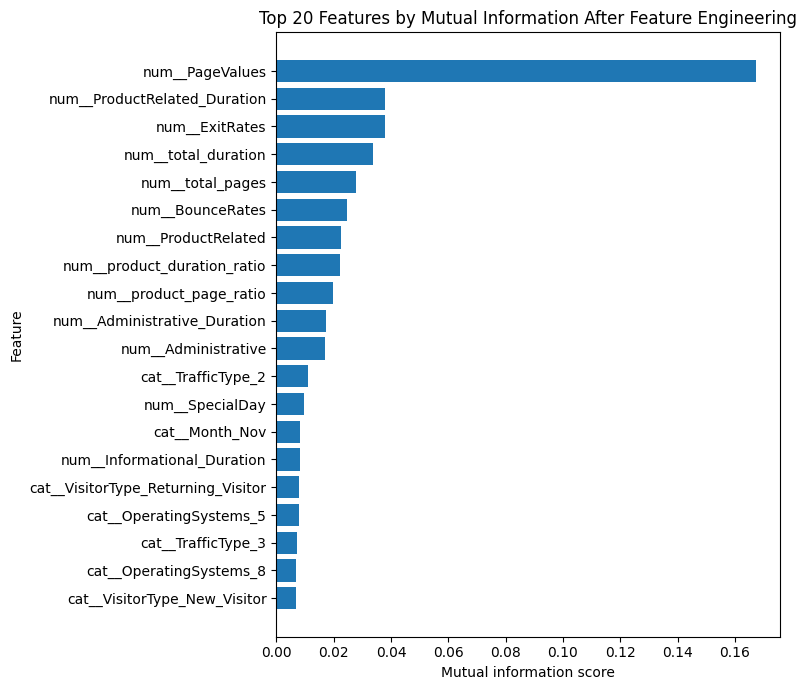

In [ ]:
top_mi_engineered_features = mi_scores_engineered_df.head(20).sort_values("mutual_information")

plt.figure(figsize=(8, 7))
plt.barh(
    top_mi_engineered_features["feature"],
    top_mi_engineered_features["mutual_information"]
)
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 20 Features by Mutual Information After Feature Engineering")
plt.tight_layout()
plt.show()

The chart shows that `PageValues` remains clearly ahead of the other features. After that, the strongest group is made up of product activity, exit behaviour and the new engineered session summaries.

This is a useful result because all four engineered features appear in the top 10. It does not prove that the models will perform better, but it gives a reasonable reason to test the engineered feature set through the baseline and tuning stages.

### Baseline modelling with engineered features

The next step is to rerun the baseline models using the engineered feature set. This keeps the comparison fair, because the same modelling process is repeated after changing the input features.

In [ ]:
engineered_baseline_results = []
engineered_trained_pipelines = {}

for model_name, model in models.items():
    results, pipeline = evaluate_model(
        model_name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    engineered_baseline_results.append(results)
    engineered_trained_pipelines[model_name] = pipeline


Logistic Regression
Confusion matrix:
[[1794  290]
 [  91  291]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.86      0.90      2084
        True       0.50      0.76      0.60       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.75      2466
weighted avg       0.88      0.85      0.86      2466


Decision Tree
Confusion matrix:
[[1889  195]
 [ 187  195]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.91      0.91      2084
        True       0.50      0.51      0.51       382

    accuracy                           0.85      2466
   macro avg       0.70      0.71      0.71      2466
weighted avg       0.85      0.85      0.85      2466


Random Forest
Confusion matrix:
[[2036   48]
 [ 207  175]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.98

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
engineered_baseline_results_df = pd.DataFrame(engineered_baseline_results)

engineered_baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.901865,0.724359,0.591623,0.651297
6,Hist Gradient Boosting,0.898216,0.707937,0.583770,0.639885
4,Support Vector Machine,0.863341,0.541284,0.772251,0.636462
0,Logistic Regression,0.845499,0.500861,0.761780,0.604361
2,Random Forest,0.896594,0.784753,0.458115,0.578512
7,MLPClassifier,0.864558,0.566667,0.534031,0.549865
1,Decision Tree,0.845093,0.500000,0.510471,0.505181
3,K-Nearest Neighbours,0.870641,0.647887,0.361257,0.463866


The engineered baseline results are quite similar to the first modelling cycle. The strongest baseline models are still the boosting models and `Support Vector Machine`.

`Gradient Boosting` performs best overall on F1 for the purchase class, with precision of 0.72, recall of 0.59 and F1-score of 0.65. `Hist Gradient Boosting` is close behind, with precision of 0.71, recall of 0.58 and F1-score of 0.64.

`Support Vector Machine` has the highest recall for purchase sessions at 0.77, but its precision is lower at 0.54. It finds more actual purchase sessions but also predicts more false positives.

`Random Forest` has high accuracy at 0.90 and strong precision for purchase sessions at 0.78, but its recall is much lower at 0.46. It is more cautious about predicting purchases.

The `MLPClassifier` again produced a convergence warning, so its baseline result should be treated carefully until it is tuned with a higher `max_iter` or early stopping.

### Tuning selected models with engineered features

The engineered feature set is not going to be used to restart the whole project from the beginning. Instead, it will be treated as a refinement of the first modelling cycle.

The baseline results show that `Gradient Boosting`, `Hist Gradient Boosting` and `Support Vector Machine` are the strongest candidates on the engineered features. `Random Forest` is also included because it was one of the strongest tuned models in the original feature cycle. This keeps the second cycle focused rather than repeating every model unnecessarily.

In [ ]:
engineered_tuned_results = []
engineered_tuned_models = {}

In [ ]:
gb_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_engineered_search = RandomizedSearchCV(
    gb_engineered_pipeline,
    param_distributions=gb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_engineered_search.best_params_)

print("\nBest CV F1:")
print(gb_engineered_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.05}

Best CV F1:
0.6609771469533354


In [ ]:
gb_engineered_best_model = gb_engineered_search.best_estimator_
gb_engineered_pred = gb_engineered_best_model.predict(X_test)

print("Tuned Gradient Boosting with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, gb_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, gb_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Gradient Boosting engineered",
    "accuracy": accuracy_score(y_test, gb_engineered_pred),
    "precision": precision_score(y_test, gb_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, gb_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, gb_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Gradient Boosting engineered"] = gb_engineered_best_model

Tuned Gradient Boosting with engineered features
Confusion matrix:
[[1991   93]
 [ 160  222]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.70      0.58      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.89      2466



The tuned `Gradient Boosting` model with engineered features chose 200 estimators, a learning rate of 0.05, maximum depth of 2 and `min_samples_leaf` of 1. During cross-validation, the best F1-score was 0.660977.

The test result is slightly less convincing. On the test set, the model reached accuracy of 0.90, precision of 0.70, recall of 0.58 and F1-score of 0.64 for the purchase class. This is lower than the engineered baseline `Gradient Boosting` F1-score of 0.651297, so the tuning has not improved the final test performance.

The confusion matrix shows 222 correctly predicted purchase sessions, but 160 purchase sessions were still missed. At this stage, the engineered features are still worth testing with the other main models, but they have not improved `Gradient Boosting`.

In [ ]:
hgb_engineered_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.001]
}

hgb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_engineered_search = RandomizedSearchCV(
    hgb_engineered_pipeline,
    param_distributions=hgb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(hgb_engineered_search.best_params_)

print("\nBest CV F1:")
print(hgb_engineered_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}

Best CV F1:
0.6712666193621987


In [ ]:
hgb_engineered_best_model = hgb_engineered_search.best_estimator_
hgb_engineered_pred = hgb_engineered_best_model.predict(X_test)

print("Tuned Hist Gradient Boosting with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, hgb_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, hgb_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Hist Gradient Boosting engineered",
    "accuracy": accuracy_score(y_test, hgb_engineered_pred),
    "precision": precision_score(y_test, hgb_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, hgb_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, hgb_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Hist Gradient Boosting engineered"] = hgb_engineered_best_model

Tuned Hist Gradient Boosting with engineered features
Confusion matrix:
[[2002   82]
 [ 151  231]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.95      2084
        True       0.74      0.60      0.66       382

    accuracy                           0.91      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.90      0.91      0.90      2466



The tuned `Hist Gradient Boosting` model with engineered features chose 100 iterations, a learning rate of 0.05, 15 leaf nodes and no L2 regularisation. The best cross-validation F1-score was 0.671267.

This result is stronger than the tuned `Gradient Boosting` model with engineered features. On the test set, it reached accuracy of 0.91, precision of 0.74, recall of 0.60 and F1-score of 0.66 for the purchase class.

The confusion matrix shows 231 correctly predicted purchase sessions and 151 missed purchase sessions. Compared with the original tuned `Hist Gradient Boosting` model, this is a small improvement in recall and F1. This is the first result in the engineered cycle that suggests the engineered features may have helped.

Original tuned Hist Gradient Boosting:
accuracy ~0.903, precision 0.729, recall 0.599, F1 0.658

Engineered tuned Hist Gradient Boosting:
accuracy about 0.91, precision 0.74, recall 0.60, F1 0.66

In [ ]:
rf_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced"]
}

rf_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_engineered_search = RandomizedSearchCV(
    rf_engineered_pipeline,
    param_distributions=rf_engineered_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_engineered_search.best_params_)

print("\nBest CV F1:")
print(rf_engineered_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1:
0.6745383171124493


In [ ]:
rf_engineered_best_model = rf_engineered_search.best_estimator_
rf_engineered_pred = rf_engineered_best_model.predict(X_test)

print("Tuned Random Forest with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, rf_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Random Forest engineered",
    "accuracy": accuracy_score(y_test, rf_engineered_pred),
    "precision": precision_score(y_test, rf_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, rf_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, rf_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Random Forest engineered"] = rf_engineered_best_model

Tuned Random Forest with engineered features
Confusion matrix:
[[1960  124]
 [ 137  245]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.94      0.94      2084
        True       0.66      0.64      0.65       382

    accuracy                           0.89      2466
   macro avg       0.80      0.79      0.80      2466
weighted avg       0.89      0.89      0.89      2466



The tuned `Random Forest` model with engineered features selected 200 trees, `max_depth` of 20, `max_features="sqrt"`, `min_samples_split` of 2, `min_samples_leaf` of 2 and balanced class weights. The best cross-validation F1-score was 0.674538.

On the test set, it reached accuracy of 0.89, precision of 0.66, recall of 0.64 and F1-score of 0.65 for the purchase class. This is a fairly balanced result, with neither precision nor recall being especially weak.

The confusion matrix shows 245 correctly predicted purchase sessions and 137 missed purchase sessions. This gives better recall than `Hist Gradient Boosting`, but with lower precision. Compared with the original tuned `Random Forest`, the engineered version is slightly weaker on F1, so the engineered features have not improved this model overall.

In [ ]:
svm_engineered_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(random_state=RANDOM_STATE))
])

svm_engineered_search = RandomizedSearchCV(
    svm_engineered_pipeline,
    param_distributions=svm_engineered_param_grid,
    n_iter=12,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_engineered_search.fit(X_train, y_train)

print("Best parameters:")
print(svm_engineered_search.best_params_)

print("\nBest CV F1:")
print(svm_engineered_search.best_score_)

Best parameters:
{'model__kernel': 'linear', 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1:
0.6558146204476824


In [ ]:
svm_engineered_best_model = svm_engineered_search.best_estimator_
svm_engineered_pred = svm_engineered_best_model.predict(X_test)

print("Tuned Support Vector Machine with engineered features")
print("Confusion matrix:")
print(confusion_matrix(y_test, svm_engineered_pred))

print("\nClassification report:")
print(classification_report(y_test, svm_engineered_pred))

engineered_tuned_results.append({
    "model": "Tuned Support Vector Machine engineered",
    "accuracy": accuracy_score(y_test, svm_engineered_pred),
    "precision": precision_score(y_test, svm_engineered_pred, pos_label=True, zero_division=0),
    "recall": recall_score(y_test, svm_engineered_pred, pos_label=True, zero_division=0),
    "f1": f1_score(y_test, svm_engineered_pred, pos_label=True, zero_division=0)
})

engineered_tuned_models["Tuned Support Vector Machine engineered"] = svm_engineered_best_model

Tuned Support Vector Machine with engineered features
Confusion matrix:
[[1861  223]
 [ 105  277]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2084
        True       0.55      0.73      0.63       382

    accuracy                           0.87      2466
   macro avg       0.75      0.81      0.77      2466
weighted avg       0.89      0.87      0.87      2466



The tuned `Support Vector Machine` with engineered features selected a linear kernel, `C=10` and balanced class weights. The best cross-validation F1-score was 0.655815.

On the test set, it reached accuracy of 0.87, precision of 0.55, recall of 0.73 and F1-score of 0.63 for the purchase class. This is the same kind of trade-off seen earlier: the model finds a relatively high number of purchase sessions, but it also makes more false purchase predictions.

The confusion matrix shows 277 correctly predicted purchase sessions and 105 missed purchase sessions. This is useful from a recall point of view, but the lower precision means it is not as balanced as the tree-based models. Compared with the original tuned SVM, the result is almost unchanged, so the engineered features have not really improved this model.

In [ ]:
engineered_tuned_results_df = pd.DataFrame(engineered_tuned_results)

engineered_tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
1,Tuned Hist Gradient Boosting engineered,0.905515,0.738019,0.604712,0.664748
2,Tuned Random Forest engineered,0.894161,0.663957,0.641361,0.652463
0,Tuned Gradient Boosting engineered,0.897405,0.704762,0.581152,0.637016
3,Tuned Support Vector Machine engineered,0.866991,0.554000,0.725131,0.628118


The engineered tuning results show that `Hist Gradient Boosting` is the strongest model in this second cycle, with an accuracy of 0.905515, precision of 0.738019, recall of 0.604712 and F1-score of 0.664748.

`Random Forest` comes second, with F1-score of 0.652463. It has better recall than `Hist Gradient Boosting`, at 0.641361, but lower precision at 0.663957. It catches more purchase sessions, but at the cost of making more false purchase predictions.

`Support Vector Machine` remains the model with the highest recall, at 0.725131, but with a precision of only 0.554000. This makes it less balanced overall. At this point, the best engineered-feature model is `Hist Gradient Boosting`.

In [ ]:
original_tuned_results_df = pd.read_csv("../outputs/tuned_results_original_features.csv")

original_tuned_results_df["feature_set"] = "Original features"
engineered_tuned_results_df["feature_set"] = "Engineered features"

final_comparison_df = pd.concat(
    [
        original_tuned_results_df,
        engineered_tuned_results_df
    ],
    # reset the index after concatenation so the final comparison table has clean row numbers
    ignore_index=True
)

final_comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,feature_set
7,Tuned Hist Gradient Boosting engineered,0.905515,0.738019,0.604712,0.664748,Engineered features
0,Tuned Random Forest,0.892944,0.650510,0.667539,0.658915,Original features
1,Tuned Hist Gradient Boosting,0.903487,0.729299,0.599476,0.658046,Original features
8,Tuned Random Forest engineered,0.894161,0.663957,0.641361,0.652463,Engineered features
2,Tuned Gradient Boosting,0.900243,0.716561,0.589005,0.646552,Original features
6,Tuned Gradient Boosting engineered,0.897405,0.704762,0.581152,0.637016,Engineered features
3,Tuned Logistic Regression,0.871046,0.565041,0.727749,0.636156,Original features
4,Tuned Support Vector Machine,0.867802,0.556000,0.727749,0.630385,Original features
9,Tuned Support Vector Machine engineered,0.866991,0.554000,0.725131,0.628118,Engineered features
5,Tuned MLPClassifier,0.886861,0.662461,0.549738,0.600858,Original features


This table brings the original tuned models and the engineered-feature tuned models together, so I can see whether the second modelling cycle actually helped.

The main result is that the engineered `Hist Gradient Boosting` model is now at the top, with an F1-score of 0.664748. It outperforms the original `Random Forest` at 0.658915 and the original `Hist Gradient Boosting` at 0.658046, but the difference is quite small.

This makes the result useful, but not completely decisive on its own. The engineered features seem to help `Hist Gradient Boosting`, but they do not improve every model. Engineered `Random Forest` is slightly weaker than the original `Random Forest`, and engineered `Support Vector Machine` is too.

The choice is also not just about the highest F1-score. The original `Random Forest` has better recall at 0.667539, so it catches more purchase sessions. The engineered `Hist Gradient Boosting` has better precision at 0.738019, so when it predicts a purchase it is more often correct.

At this point, I am leaning towards engineered `Hist Gradient Boosting` because it has the best overall F1-score and accuracy. Before making this final, I still need to check whether the small gain is enough to justify the extra engineered features, and whether the precision-recall trade-off fits the aim of predicting purchase intention.

Questions I still have include: 

Does engineered Hist Gradient Boosting really win? 

Is Random Forest still better because of recall? 

Is the engineered gain big enough to justify the extra features?

## Final contender analysis

In [ ]:
top_contenders = final_comparison_df[
    final_comparison_df["model"].isin([
        "Tuned Hist Gradient Boosting engineered",
        "Tuned Random Forest",
        "Tuned Hist Gradient Boosting",
        "Tuned Random Forest engineered"
    ])
].copy()

top_contenders.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,feature_set
7,Tuned Hist Gradient Boosting engineered,0.905515,0.738019,0.604712,0.664748,Engineered features
0,Tuned Random Forest,0.892944,0.650510,0.667539,0.658915,Original features
1,Tuned Hist Gradient Boosting,0.903487,0.729299,0.599476,0.658046,Original features
8,Tuned Random Forest engineered,0.894161,0.663957,0.641361,0.652463,Engineered features


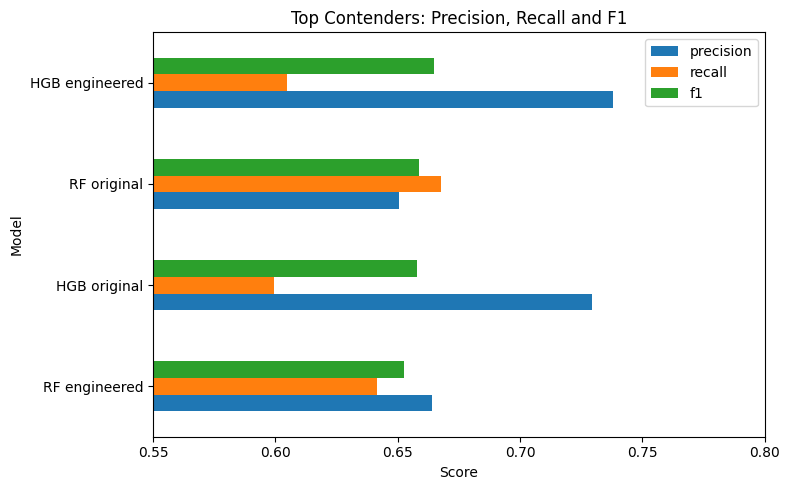

In [ ]:
top_contenders_plot = top_contenders.copy()

top_contenders_plot["model"] = top_contenders_plot["model"].replace({
    "Tuned Hist Gradient Boosting engineered": "HGB engineered",
    "Tuned Random Forest": "RF original",
    "Tuned Hist Gradient Boosting": "HGB original",
    "Tuned Random Forest engineered": "RF engineered"
})

top_contenders_plot = top_contenders_plot.sort_values(by="f1", ascending=True)

top_contenders_plot.plot(
    x="model",
    y=["precision", "recall", "f1"],
    kind="barh",
    figsize=(8, 5)
)

# zoom in on the top-contender range so the small differences are easier to compare
plt.xlim(0.55, 0.8)
plt.xlabel("Score")
plt.ylabel("Model")
plt.title("Top Contenders: Precision, Recall and F1")
plt.tight_layout()
plt.show()

This chart zooms in on the top contender score range, so the differences between the models are easier to see.

`HGB engineered` has the highest F1-score and the strongest precision. `RF original` has the strongest recall, identifying more of the actual purchase sessions. 

`HGB engineered` is the best balanced model overall, but `RF original` is still important if recall is the priority.

The chart also shows that the engineered features only improved one of the main contenders. `HGB engineered` is better than `HGB original`, but `RF engineered` is weaker than `RF original`. This makes the final choice more cautious rather than a simple claim that feature engineering improved everything.

## Confusion matrices for final contenders

In [ ]:
X_original = df.drop(columns=["Revenue"])
y_original = df["Revenue"]

_, X_test_original, _, y_test_original = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    stratify=y_original,
    random_state=RANDOM_STATE
)

print("Cycle 2 Engineered Hist Gradient Boosting")
print(confusion_matrix(y_test, hgb_engineered_pred))

print("\nCycle 1 Random Forest")
rf_original_pred = rf_search.predict(X_test_original)
print(confusion_matrix(y_test_original, rf_original_pred))

print("\nCycle 1 Hist Gradient Boosting")
hgb_original_pred = hgb_search.predict(X_test_original)
print(confusion_matrix(y_test_original, hgb_original_pred))

print("\nCycle 2 Engineered Random Forest")
print(confusion_matrix(y_test, rf_engineered_pred))

Cycle 2 Engineered Hist Gradient Boosting
[[2002   82]
 [ 151  231]]

Cycle 1 Random Forest
[[1947  137]
 [ 127  255]]

Cycle 1 Hist Gradient Boosting
[[1999   85]
 [ 153  229]]

Cycle 2 Engineered Random Forest
[[1960  124]
 [ 137  245]]


The confusion matrices make the trade-off clearer than the score table on its own.

`Cycle 2 Engineered Hist Gradient Boosting` has the fewest false positives, with 82 non-purchase sessions wrongly predicted as purchases. This explains why its precision is strong. It is more careful when it predicts a purchase. However, it misses 151 actual purchase sessions.

`Cycle 1 Random Forest` finds more purchase sessions overall, with 255 true positives compared with 231 for `Cycle 2 Engineered Hist Gradient Boosting`. It also has fewer false negatives, missing 127 purchase sessions instead of 151. This explains why it has the strongest recall. The drawback is that it also makes more false purchase predictions, with 137 false positives.

The two `Hist Gradient Boosting` models are very similar. The engineered version improves the result slightly, with 231 true positives and 82 false positives, compared with 229 true positives and 85 false positives for the original version. This is an improvement, but not a large one.

`Cycle 2 Engineered Random Forest` sits between the two main contenders. It finds 245 purchase sessions, which is better than both `Hist Gradient Boosting` models, but it also has 124 false positives. This makes it more recall-focused than `Hist Gradient Boosting`, but less strong overall than the original `Random Forest`.

At this stage, `Cycle 2 Engineered Hist Gradient Boosting` is the strongest model by F1-score and precision, while `Cycle 1 Random Forest` remains the strongest model for recall. The final model choice should therefore depend on whether the task values more selective purchase prediction or catching as many purchase sessions as possible.


### Permutation importance for the leading Hist Gradient Boosting contender

After all the tuning and feature engineering, what does the Hist Gradient Boosting model actually rely on?

In [ ]:
from sklearn.inspection import permutation_importance

hgb_engineered_perm = permutation_importance(
    hgb_engineered_best_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

hgb_engineered_importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": hgb_engineered_perm.importances_mean,
        "importance_std": hgb_engineered_perm.importances_std
    })
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

hgb_engineered_importance_df.head(15)

,feature,importance_mean,importance_std
0,PageValues,0.488391,0.020465
1,Month,0.065654,0.007376
2,ExitRates,0.049963,0.010809
3,BounceRates,0.018106,0.006692
4,total_pages,0.013913,0.007859
5,TrafficType,0.009240,0.003078
6,total_duration,0.005518,0.005706
7,Administrative,0.004473,0.004367
8,ProductRelated_Duration,0.004403,0.004931
9,product_page_ratio,0.003722,0.003041


Permutation importance was used to check which features the tuned `Hist Gradient Boosting` model relied on most. This method shuffles one feature at a time and measures how much the model’s F1-score drops. If the score drops a lot, the feature is important because the model needed it for accurate classification [10].

The results show that `PageValues` is by far the most important feature, with an importance mean of `0.488391`. This is much higher than the next strongest features, `Month` at `0.065654` and `ExitRates` at `0.049963`. This suggests that the model is mainly using `PageValues`, with timing and behavioural exit-rate information adding further value.

The engineered features appear in the top 15, but their effect is smaller. `total_pages` has the strongest engineered-feature importance at `0.013913`, followed by `total_duration`, `product_page_ratio` and `product_duration_ratio`. This supports the earlier result that the engineered features helped slightly, but did not replace the original behavioural features as the main source of predictive information.

[10] scikit-learn developers, “Permutation feature importance,” scikit-learn User Guide. Available: https://scikit-learn.org/stable/modules/permutation_importance.html

QUESTIONS I STILL HAVE:

Does the recall-focused RF original rely on similar features?

Do the engineered features actually add useful information to the HGB model?

Is the HGB gain meaningful enough to justify choosing the engineered cycle?

Or is the simpler original Random Forest better because it catches more purchase sessions?


### Permutation importance for the original Random Forest contender

In [ ]:
rf_original_best_model = rf_search.best_estimator_

rf_original_perm = permutation_importance(
    rf_original_best_model,
    X_test_original,
    y_test_original,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

rf_original_importance_df = (
    pd.DataFrame({
        "feature": X_test_original.columns,
        "importance_mean": rf_original_perm.importances_mean,
        "importance_std": rf_original_perm.importances_std
    })
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

rf_original_importance_df.head(15)

,feature,importance_mean,importance_std
0,PageValues,0.455524,0.022402
1,Month,0.035170,0.007215
2,ExitRates,0.034860,0.012221
3,BounceRates,0.022851,0.005354
4,ProductRelated,0.013988,0.007893
5,ProductRelated_Duration,0.008851,0.006420
6,Weekend,0.004337,0.004037
7,TrafficType,0.004067,0.005521
8,OperatingSystems,0.002601,0.003459
9,SpecialDay,0.002539,0.003882


The `Random Forest` permutation importance results show a similar pattern to the engineered `Hist Gradient Boosting` model. `PageValues` is again the strongest feature by a large margin, with an importance mean of `0.455524`. Both final contenders mainly rely on the same strongest signal, which is whether the session reached pages that were already associated with purchase value.

The next most useful features are `Month`, `ExitRates` and `BounceRates`, although their scores are much lower. This makes sense because these features describe when the visit happened and how the user behaved during the session, but they are not as directly linked to purchase intention as `PageValues`.

For the original `Random Forest`, the useful supporting features are more directly tied to the original browsing activity columns, such as `ProductRelated` and `ProductRelated_Duration`. This may help explain why it has stronger recall, although the feature importance results do not prove this on their own. What the evaluation does show clearly is that the model identifies more purchase sessions, but also makes more false positive predictions.

### Comparing feature importance between the final contenders

In [ ]:
hgb_importance_plot_df = hgb_engineered_importance_df.copy()
hgb_importance_plot_df["model"] = "HGB engineered"

rf_importance_plot_df = rf_original_importance_df.copy()
rf_importance_plot_df["model"] = "RF original"

combined_importance_df = pd.concat(
    [hgb_importance_plot_df, rf_importance_plot_df],
    ignore_index=True
)

engineered_features = [
    "total_pages",
    "total_duration",
    "product_page_ratio",
    "product_duration_ratio"
]

top_features_overall = (
    combined_importance_df
    .groupby("feature")["importance_mean"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

features_for_comparison = list(dict.fromkeys(
    top_features_overall + engineered_features
))

importance_comparison_df = (
    combined_importance_df[
        combined_importance_df["feature"].isin(features_for_comparison)
    ]
    .pivot(index="feature", columns="model", values="importance_mean")
    .fillna(0)
    .loc[features_for_comparison]
)

importance_comparison_df

model,HGB engineered,RF original
feature,,
PageValues,0.488391,0.455524
Month,0.065654,0.035170
ExitRates,0.049963,0.034860
BounceRates,0.018106,0.022851
ProductRelated,0.001205,0.013988
total_pages,0.013913,0.000000
TrafficType,0.009240,0.004067
ProductRelated_Duration,0.004403,0.008851
total_duration,0.005518,0.000000


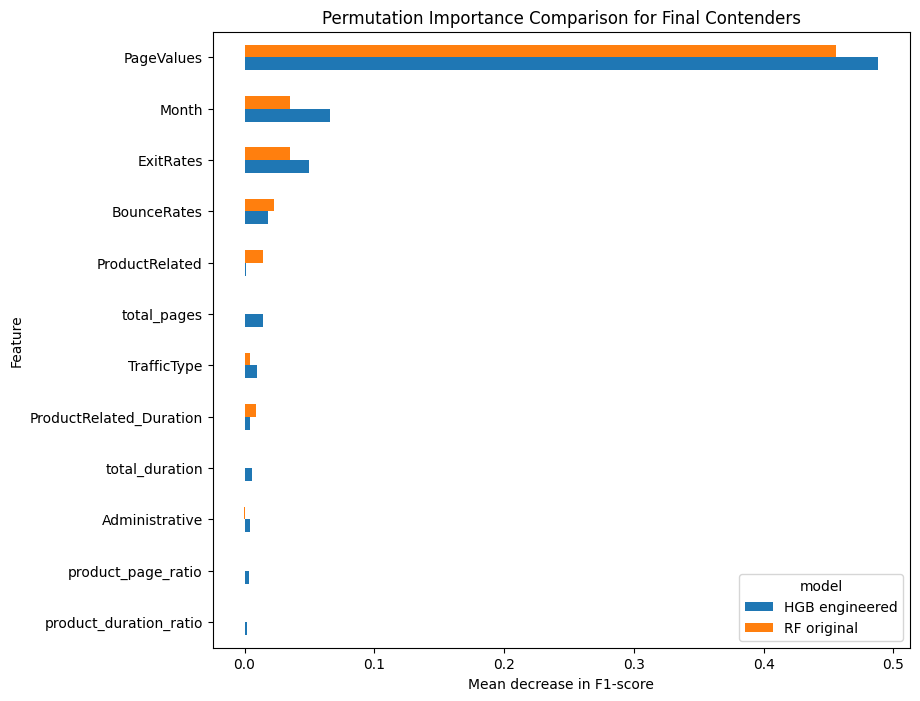

In [ ]:
importance_comparison_df.iloc[::-1].plot(
    kind="barh",
    figsize=(9, 8)
)

plt.title("Permutation Importance Comparison for Final Contenders")
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.show()

The full comparison plot shows that `PageValues` dominates both final contenders. This is useful because it confirms that both models rely most heavily on the same strongest feature. However, because `PageValues` is so much larger than the other values, the smaller supporting features are difficult to compare properly in this version of the plot.

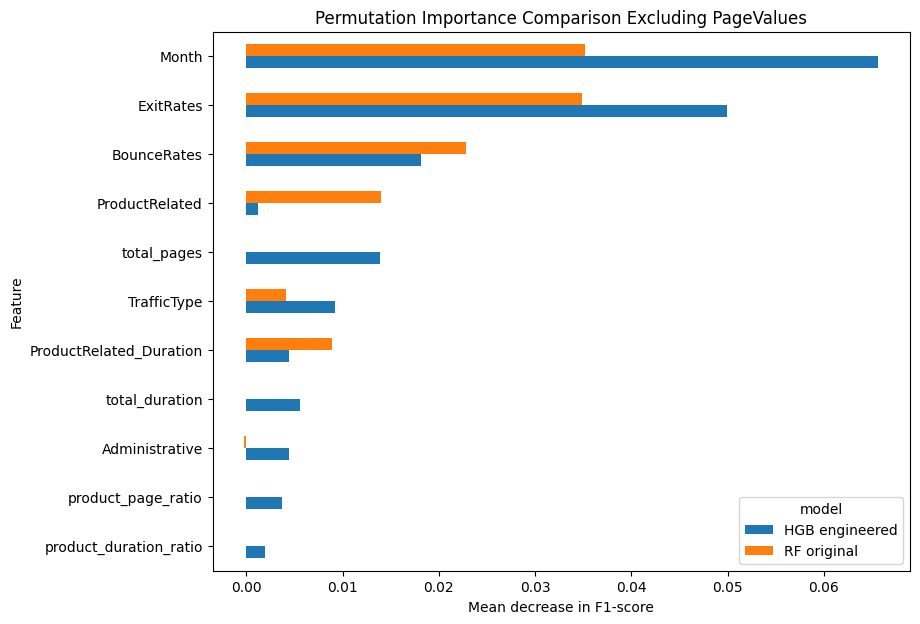

In [ ]:
importance_comparison_without_pagevalues = importance_comparison_df.drop(
    index="PageValues"
)

importance_comparison_without_pagevalues.iloc[::-1].plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Permutation Importance Comparison Excluding PageValues")
plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.show()

After removing `PageValues` from the plot, the smaller feature differences become easier to see. Both models still use `Month`, `ExitRates` and `BounceRates` as supporting features, but the balance is slightly different.

The engineered `Hist Gradient Boosting` model gives some importance to `total_pages`, `total_duration`, `product_page_ratio` and `product_duration_ratio`. These features are not as influential as the main behavioural variables, but they do show that the engineered features contributed some useful extra information. This helps explain why the engineered `Hist Gradient Boosting` model made a small improvement in F1-score, rather than a dramatic change in performance.

## Final model choice

The final selected model is `Tuned Hist Gradient Boosting engineered`. This model is selected because F1-score was used as the main metric for the project, and it achieved the highest F1-score at `0.664748`. This is appropriate because the target variable is imbalanced, so accuracy alone would not give enough information about performance on purchase sessions.

The model also has the highest precision at `0.738019` and the highest accuracy at `0.905515`. Its confusion matrix shows that it makes the fewest false positive purchase predictions, with 82 false positives. This makes it the strongest option if the aim is to identify likely purchase sessions without over-targeting too many non-purchase sessions.

The main alternative is `Tuned Random Forest` using the original features. This model has the strongest recall at `0.667539`, and it correctly identifies 255 purchase sessions compared with 231 for the engineered `Hist Gradient Boosting` model. However, it also produces more false positives, with 137 compared with 82. This means it would be preferred if the business aim was to catch as many potential purchasers as possible, but it is less selective.

The permutation importance results also support the final choice. Both final contenders rely strongly on `PageValues`, with `Month`, `ExitRates` and `BounceRates` acting as useful supporting features. The engineered `Hist Gradient Boosting` model also makes some use of the engineered features, especially `total_pages`, although their contribution is much smaller than `PageValues`. This suggests that feature engineering added a small improvement rather than changing the whole basis of the prediction.

Overall, `Tuned Hist Gradient Boosting engineered` is chosen as the final model because it gives the best balance between precision and recall, performs best on F1-score, and keeps false positives lower than the recall-focused Random Forest alternative.